# Notebook 1: Introduction to GeoPandas and Spatial Data

**CCOM 6994: Data Analysis Tools - Final Project**  
**Course: Análisis de Datos de Paneles Solares**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Load geospatial data** from cloud storage (S3/R2) using pandas
2. **Work with GeoPandas** data structures (GeoDataFrame, GeoSeries)
3. **Convert between coordinate formats** (WKT to Shapely geometries)
4. **Perform basic spatial operations** (centroid, area, bounding box)
5. **Filter spatial data** by bounding box and attribute conditions
6. **Understand coordinate reference systems** (CRS) and projections

---

## 📚 Key Concepts

### What is Geospatial Data?

Geospatial data represents features on Earth's surface. Each record has:
- **Attributes**: Regular data (text, numbers, dates)
- **Geometry**: Spatial representation (points, lines, polygons)
- **Coordinate Reference System (CRS)**: How coordinates map to Earth's surface

### Vector Data Types

- **Point**: Single coordinate (e.g., solar panel centroid)
- **LineString**: Connected coordinates (e.g., road, river)
- **Polygon**: Closed shape (e.g., solar panel boundary, country)
- **Multi-* types**: Collections of geometries

### GeoPandas = Pandas + Geometries

GeoPandas extends pandas DataFrames with:
- `GeoDataFrame`: DataFrame with geometry column
- `GeoSeries`: Series of geometries
- Spatial operations (intersects, contains, buffer, etc.)
- Coordinate transformations
- Map visualization

---

## 🔧 Setup: Import Required Libraries

In [1]:
import os
from datetime import datetime
import time
import random

import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
from shapely import wkt, wkb
from shapely.geometry import Point, Polygon, box
import geopy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from dotenv import load_dotenv

# Load environment variables from .env file in repo root in parent directory
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), '../.env'))

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

---

## 📥 Task 1: Fetching Solar Panel Data from S3

### About Our Dataset

We're working with a **consolidated global solar panel (PV) dataset** that includes:
- Solar panel installations from multiple sources (USA, UK, China, India, global)
- Geographic coordinates and polygon boundaries
- Installation metadata (area, capacity, dates)
- Spatial indices (H3 hexagon cells)

### Data Format: GeoParquet

**GeoParquet** is an efficient cloud-native format for geospatial data:
- Columnar storage (fast queries, good compression)
- Embedded spatial metadata (CRS, bounding boxes)
- Works with pandas, GeoPandas, DuckDB, and other tools
- Stored in **Cloudflare R2** (S3-compatible object storage)

### Reading Strategy

We'll use **pandas + s3fs** to read the parquet file:
1. Connect to S3-compatible storage (R2) with credentials
2. Read parquet file into pandas DataFrame
3. Convert WKT geometry strings to Shapely objects
4. Create GeoDataFrame with proper CRS

In [2]:
def read_parquet_with_pandas(
    path: str,
    use_pyarrow: bool = True
) -> gpd.GeoDataFrame:
    """
    Read a Parquet file into a GeoDataFrame.
    """
    print(f"Reading data from {path}...")
    engine = 'pyarrow' if use_pyarrow else 'fastparquet'
    df = pd.read_parquet(path, engine=engine)
    
    # convert to geodataframe and convert WKT to shapely
    if 'geometry' in df.columns and df['geometry'].dtype == 'object':
        df['geometry'] = df['geometry'].apply(wkt.loads)

    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
    return gdf

# Define Dataset URI and AOI
DATASET_URI = os.getenv('CONSOLIDATED_PV_DATASET_FILE', 's3://eo-pv-lakehouse/geoparquet/ccom6994_pv_dataset.parquet')

# Fetch and Filter
t1 = time.time()
full_gdf = read_parquet_with_pandas(DATASET_URI)
t2 = time.time()
print(f"Full Dataset fetched in {t2 - t1:.2f} seconds.")

print(f"Loaded {len(full_gdf):,} PV installations within AOI.")

# Display count by dataset name
print("\nCounts by Dataset Source:")
print(full_gdf.groupby('dataset_name').size())

# Display basic info
print(f"\n📊 Dataset Overview:")
print(f"   Shape: {full_gdf.shape}")
print(f"   Memory: {full_gdf.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\n   Columns: {list(full_gdf.columns)}")

full_gdf.sample(5)

Reading data from https://eo-pv-elt.work/geoparquet/ccom6994_pv_dataset.parquet...
Full Dataset fetched in 11.16 seconds.
Loaded 443,747 PV installations within AOI.

Counts by Dataset Source:
dataset_name
chn_med_res_pv_2024                           3355
global_harmonized_large_solar_farms_2020     35271
global_pv_inventory_sent2_spot_2021         119057
ind_pv_solar_farms_2022                       1285
uk_crowdsourced_pv_2020                     265406
usa_cali_usgs_pv_2016                        19373
dtype: int64

📊 Dataset Overview:
   Shape: (443747, 11)
   Memory: 97.1 MB

   Columns: ['dataset_name', 'processed_at', 'geometry', 'area_m2', 'centroid_lat', 'centroid_lon', 'h3_index_8', 'unified_id', 'source_area_m2', 'capacity_mw', 'install_date']


,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date
99523,uk_crowdsourced_pv_2020,2025-09-26 03:24:41.535000+00:00,POINT (-1.2689 53.49545),0.000000,53.495451,-1.268901,612933890614493183,7018096667,0.0,NaN,None
4476,usa_cali_usgs_pv_2016,2025-09-26 03:24:58.477000+00:00,"POLYGON ((-121.27388 38.06105, -121.27388 38.0...",20.815639,38.061060,-121.273913,613196956719644671,17867,NaN,NaN,None
256042,uk_crowdsourced_pv_2020,2025-09-26 03:24:41.535000+00:00,POINT (-0.99891 50.78767),0.000000,50.787671,-0.998914,612935513329893375,6790567077,0.0,NaN,None
173635,uk_crowdsourced_pv_2020,2025-09-26 03:24:41.535000+00:00,POINT (-3.06143 52.98402),0.000000,52.984019,-3.061425,612935853009797119,6705028570,0.0,NaN,None
346770,uk_crowdsourced_pv_2020,2025-09-26 03:24:41.535000+00:00,POINT (1.0175 51.25065),0.000000,51.250647,1.017499,612934326146826239,6787327660,0.0,NaN,None


In [3]:
# Collection of bounding boxes covering USA (including PR,HI,AK,Guam+USVI)
# Format: (xmin/west, ymin/south, xmax/east, ymax/north) in WGS84 degrees
AOI_bboxes = [
    os.getenv('CONUS_BBOX', '-125.0,24.0,-66.5,49.5'),  # CONUS
    os.getenv('ALASKA_BBOX', '-170.0,51.0,-130.0,72.0'),  # Alaska
    os.getenv('HAWAII_BBOX', '-161.0,18.5,-154.5,23.0'),  # Hawaii
    os.getenv('GUAM_BBOX', '144.5,13.2,145.0,13.6'),  # Guam
    os.getenv('USVI_BBOX', '-65.1,17.6,-64.5,18.6'),   # US Virgin Islands
    os.getenv('PUERTO_RICO_BBOX', '-67.3,17.9,-65.2,18.5')  # Puerto Rico
]
# Parse AOI bounding boxes into list of float tuples
AOI_bboxes = [ tuple(map(float, bbox_str.split(','))) for bbox_str in AOI_bboxes ]


t1 = time.time()
# Coordinate based indexer to select by intersection with bounding box: https://geopandas.org/en/stable/docs/user_guide/indexing.html
# apply indexing via all bboxes and concatenate into single gdf
pv_df = pd.concat([full_gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]] for bbox in AOI_bboxes])

# keep separate gdf copy for spatial operations and visualizations
pv_gdf = pv_df.copy()
# replace geometry column with WKT text to explore geometry data types and conversion below
pv_df['geometry'] = pv_df['geometry'].apply(lambda geom: geom.wkt if geom else None)

# handle geometry column for gdf
if pv_gdf.geometry.dtype == 'object':
    pv_gdf['geometry'] = pv_gdf['geometry'].apply(wkt.loads)
# use global geographic CRS for now; TODO: ID relevant CRS's for CONUS, caribbean, and pacific regions
pv_gdf = gpd.GeoDataFrame(pv_gdf, geometry='geometry', crs='EPSG:4326')
t2 = time.time()
# Filter by Bounding Box
print(f"Used Geopandas coordinates-based indexing to filter dataset to {len(AOI_bboxes)} AOI's in {t2 - t1:.2f} seconds...")

# quickly overlay bbox over plotly basemap
import plotly.express as px
# use scatter_map as scatter_mapbox is deprecated
fig = px.scatter_map(
    pv_gdf,
    lat='centroid_lat',
    lon='centroid_lon',
    zoom=2,
    height=700
)

# plot multiple AOIs in global map 
for AOI_BBOX in AOI_bboxes:

    # add bbox as line trace
    fig.add_trace(
        px.scatter_map(
            pd.DataFrame({
                'lon': [AOI_BBOX[0], AOI_BBOX[2], AOI_BBOX[2], AOI_BBOX[0], AOI_BBOX[0]],
                'lat': [AOI_BBOX[1], AOI_BBOX[1], AOI_BBOX[3], AOI_BBOX[3], AOI_BBOX[1]]
            }),
            lat='lat',
            lon='lon'
        ).data[0]
    )

    # update bbox line style
    fig.data[-1].update(
        mode='lines',
        line=dict(color='red', width=2),
        showlegend=False
    )

# show final map with AOI bounding boxes
fig.update_layout(title="USA Bounding Box for Solar Panel Dataset")
# config map projection and other geo config
fig.update_geos(projection_type="orthographic")
# use pre-configred mapbox style
# fig.update_layout(mapbox_style="satellite-streets") 
fig.show()

/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_42920/4024633513.py:23: UserWarning: Geometry column does not contain geometry.
  pv_df['geometry'] = pv_df['geometry'].apply(lambda geom: geom.wkt if geom else None)


Used Geopandas coordinates-based indexing to filter dataset to 6 AOI's in 0.51 seconds...


In [4]:
# load dataset with duckdb leveraging bbox spatial predicate to get filtered dataset and reduce data transfer

# cast bbox coords as floats to avoid ST_MakeEnvelope type mismatch with parsing as Decimal
print(f"\nQuerying dataset with DuckDB for AOI filtering...")
# get global extent of our filtered gdf to use as initial bbox filter for parquet scan
global_bounds = [float(coord) for coord in pv_gdf.total_bounds]  # returns (minx, miny, maxx, maxy)
print(f"Global bounds of filtered AOI dataset: {global_bounds}")
casted_coords = ', '.join(f"CAST({coord} AS DOUBLE)" for coord in global_bounds)
intersect_query = f"""WITH pv_data AS (
    SELECT *
    FROM read_parquet('{DATASET_URI}')
    WHERE ST_Within(ST_GeomFromText(geometry), ST_MakeEnvelope({casted_coords}))
) 
"""
# handle multiple bboxes by unioning results
for idx, AOI_BBOX in enumerate(AOI_bboxes):
    
    bbox_coords = ', '.join([str(coord) for coord in AOI_BBOX])
    casted_coords = ', '.join(f"CAST({coord} AS DOUBLE)" for coord in AOI_BBOX)
    # handle WKT geometry in our dataset
    query = f"""
        SELECT *
        FROM pv_data
        WHERE ST_Within(ST_GeomFromText(geometry), ST_MakeEnvelope({casted_coords}))
    """
    if idx != len(AOI_bboxes) - 1:
        query += """
        UNION ALL
        """
    intersect_query += query

t1 = time.time()
conn = duckdb.connect(database=':memory:')
conn.execute("INSTALL spatial; LOAD spatial;")
conn.execute("INSTALL httpfs; LOAD httpfs;")
print(f"Fetching PV dataset filtered to our {len(AOI_bboxes)} using the following DuckDB query:\n{intersect_query}\n")
ddb_df = conn.execute(intersect_query).df()
conn.close()

# handle geometry column for gdf
if ddb_df.geometry.dtype == 'object':
    ddb_df['geometry'] = ddb_df['geometry'].apply(wkt.loads)
# use global geographic CRS for now; TODO: ID relevant CRS's for CONUS, caribbean, and pacific regions
t2 = time.time()
ddb_gdf = gpd.GeoDataFrame(ddb_df, geometry='geometry', crs='EPSG:4326')

print(f"Loaded {len(ddb_gdf):,} PV installations within AOI using DuckDB.")
print(f"Dataset loaded in {t2 - t1:.2f} seconds")


Querying dataset with DuckDB for AOI filtering...
Global bounds of filtered AOI dataset: [-159.58423002975542, 13.30037844818687, 144.75494430000003, 68.35970379999942]
Fetching PV dataset filtered to our 6 using the following DuckDB query:
WITH pv_data AS (
    SELECT *
    FROM read_parquet('https://eo-pv-elt.work/geoparquet/ccom6994_pv_dataset.parquet')
    WHERE ST_Within(ST_GeomFromText(geometry), ST_MakeEnvelope(CAST(-159.58423002975542 AS DOUBLE), CAST(13.30037844818687 AS DOUBLE), CAST(144.75494430000003 AS DOUBLE), CAST(68.35970379999942 AS DOUBLE)))
) 

        SELECT *
        FROM pv_data
        WHERE ST_Within(ST_GeomFromText(geometry), ST_MakeEnvelope(CAST(-124.9590696112 AS DOUBLE), CAST(24.4757356044 AS DOUBLE), CAST(-67.3409665939 AS DOUBLE), CAST(49.0774997393 AS DOUBLE)))
    
        UNION ALL
        
        SELECT *
        FROM pv_data
        WHERE ST_Within(ST_GeomFromText(geometry), ST_MakeEnvelope(CAST(-168.233052623 AS DOUBLE), CAST(53.5226880081 AS DOUBL

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 42,669 PV installations within AOI using DuckDB.
Dataset loaded in 13.89 seconds


In [5]:
print(f"Loaded {len(pv_df):,} PV installations within AOI.")
    
# Display count by dataset name
print("\nCounts by Dataset Source:")
display(pv_df.groupby('dataset_name').size())

# Display basic info
print(f"\n📊 Dataset Overview:")
print(f"   Shape: {pv_df.shape}")
print(f"\n   Columns: {list(pv_gdf.columns)}")

Loaded 42,669 PV installations within AOI.

Counts by Dataset Source:


dataset_name
global_harmonized_large_solar_farms_2020     4234
global_pv_inventory_sent2_spot_2021         19062
usa_cali_usgs_pv_2016                       19373
dtype: int64


📊 Dataset Overview:
   Shape: (42669, 11)

   Columns: ['dataset_name', 'processed_at', 'geometry', 'area_m2', 'centroid_lat', 'centroid_lon', 'h3_index_8', 'unified_id', 'source_area_m2', 'capacity_mw', 'install_date']


### Understanding the Dataset

Let's examine what we've loaded:

In [6]:
# Show first few rows
print("📋 First 5 records:\n")
display(pv_df.head())

# Check data types
print("\n📊 Column Data Types:\n")
print(pv_df.dtypes)

# Summary statistics for numeric columns
print("\n📈 Summary Statistics:\n")
display(pv_df.describe())

📋 First 5 records:



,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date
1074,global_pv_inventory_sent2_spot_2021,2025-09-26 03:24:11.103000+00:00,POLYGON ((-112.78301352411961 30.8364272674048...,7159.833778,30.836328,-112.782517,613761905630117887,52106.0,5278.617241,0.522328,
1075,global_pv_inventory_sent2_spot_2021,2025-09-26 03:24:11.103000+00:00,POLYGON ((-111.84567847542456 30.9485581520007...,12403.986133,30.948465,-111.845144,613772448107593727,52101.0,9123.498114,0.906640,
1076,global_pv_inventory_sent2_spot_2021,2025-09-26 03:24:11.103000+00:00,POLYGON ((-112.18820028354554 30.6577951308371...,5911.787321,30.657751,-112.187719,613761909514043391,52093.0,4374.681694,0.436518,
1077,global_pv_inventory_sent2_spot_2021,2025-09-26 03:24:11.103000+00:00,POLYGON ((-111.83554331195809 30.5940710731885...,16819.527200,30.594536,-111.834990,613761914515750911,22210.0,12462.602984,1.149856,2016-06-19
1078,global_pv_inventory_sent2_spot_2021,2025-09-26 03:24:11.103000+00:00,POLYGON ((-111.83753079147725 30.5941259747518...,6634.855575,30.594357,-111.836763,613761914524139519,22212.0,4916.183310,0.490621,2016-06-19



📊 Column Data Types:

dataset_name                   object
processed_at      datetime64[us, UTC]
geometry                       object
area_m2                       float64
centroid_lat                  float64
centroid_lon                  float64
h3_index_8                      int64
unified_id                     object
source_area_m2                float64
capacity_mw                   float64
install_date                   object
dtype: object

📈 Summary Statistics:



,area_m2,centroid_lat,centroid_lon,h3_index_8,source_area_m2,capacity_mw
count,4.266900e+04,42669.000000,42669.000000,4.266900e+04,8.054000e+03,9319.000000
mean,5.899483e+04,36.557811,-110.132192,6.133243e+17,8.995555e+04,8.543933
std,4.780657e+05,3.046475,16.275703,2.174710e+14,3.358455e+05,28.898496
min,0.000000e+00,13.303155,-159.582985,6.127029e+17,3.696870e+02,0.040196
25%,3.172929e+01,34.597008,-119.774157,6.132220e+17,5.082542e+03,0.577652
50%,8.546610e+01,36.805579,-119.213967,6.132226e+17,1.496288e+04,1.641172
75%,4.757406e+03,37.601850,-110.826143,6.132400e+17,5.028357e+04,5.541398
max,3.352269e+07,68.357890,144.749554,6.141272e+17,1.111768e+07,900.066591


**Key Observations:**

- `geometry` column contains WKT (Well-Known Text) strings
- `centroid_lon`, `centroid_lat` are regular numeric columns
- `area_m2` shows panel size in square meters
- `h3_index_8` contains H3 spatial index (we'll explore this later)

---

## 🗺️ Task 2: Converting to GeoDataFrame

### From WKT to Shapely Geometries

**Well-Known Text (WKT)** is a standard text format for geometries:
- `POINT (lon lat)`
- `POLYGON ((lon1 lat1, lon2 lat2, ...))`
- `MULTIPOLYGON (((lon lat, ...), (...)))`

We need to convert these strings to **Shapely geometry objects** for spatial operations.

In [7]:
def create_geodataframe(
    df: pd.DataFrame,
    geometry_col: str = 'geometry',
    crs: str = 'EPSG:4326'
) -> gpd.GeoDataFrame:
    """
    Convert pandas DataFrame with WKT geometries to GeoDataFrame.
    
    Args:
        df: DataFrame with WKT geometry column
        geometry_col: Name of geometry column
        crs: Coordinate Reference System (default: WGS84/EPSG:4326)
        
    Returns:
        GeoDataFrame with Shapely geometries
    """
    print(f"🔄 Converting DataFrame to GeoDataFrame...")
    
    # Convert WKT strings to Shapely geometries
    print(f"   📐 Parsing {len(df):,} WKT geometries...")
    df = df.copy()
    # confirm geometry is in WKT format
    if df[geometry_col].dtype == 'object':
        df[geometry_col] = df[geometry_col].apply(wkt.loads)
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=geometry_col, crs=crs)
    
    print(f"✅ GeoDataFrame created:")
    print(f"   CRS: {gdf.crs}")
    print(f"   Geometry types: {gdf.geometry.geom_type.value_counts().to_dict()}")
    print(f"   Valid geometries: {gdf.geometry.is_valid.sum():,} / {len(gdf):,}")
    
    return gdf


# Convert to GeoDataFrame
pv_gdf = create_geodataframe(pv_df, geometry_col='geometry')

# Show GeoDataFrame info
print("\n📋 GeoDataFrame Preview:")
display(pv_gdf.head(3))

🔄 Converting DataFrame to GeoDataFrame...
   📐 Parsing 42,669 WKT geometries...
✅ GeoDataFrame created:
   CRS: EPSG:4326
   Geometry types: {'Polygon': 40369, 'MultiPolygon': 1639, 'Point': 375, 'MultiPoint': 286}
   Valid geometries: 42,669 / 42,669

📋 GeoDataFrame Preview:


,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date
1074,global_pv_inventory_sent2_spot_2021,2025-09-26 03:24:11.103000+00:00,"POLYGON ((-112.78301 30.83643, -112.78301 30.8...",7159.833778,30.836328,-112.782517,613761905630117887,52106.0,5278.617241,0.522328,
1075,global_pv_inventory_sent2_spot_2021,2025-09-26 03:24:11.103000+00:00,"POLYGON ((-111.84568 30.94856, -111.84568 30.9...",12403.986133,30.948465,-111.845144,613772448107593727,52101.0,9123.498114,0.906640,
1076,global_pv_inventory_sent2_spot_2021,2025-09-26 03:24:11.103000+00:00,"POLYGON ((-112.1882 30.6578, -112.1882 30.6577...",5911.787321,30.657751,-112.187719,613761909514043391,52093.0,4374.681694,0.436518,


### What's Different in a GeoDataFrame?

Compare these operations:

In [8]:
print("🔍 Comparing DataFrame vs GeoDataFrame:\n")

# Regular DataFrame operations still work
print("1️⃣ Regular operations (same as pandas):")
print(f"   Mean area: {pv_gdf['area_m2'].mean():.2f} m²")
print(f"   Datasets: {pv_gdf['dataset_name'].nunique()} unique sources")

# New geometric operations
print("\n2️⃣ Geometric operations (new!):")
print(f"   Geometry type: {type(pv_gdf.geometry.iloc[0])}")
print(f"   First centroid: {pv_gdf.geometry.iloc[0].centroid}")
print(f"   First area: {pv_gdf.geometry.iloc[0].area:.8f} square degrees")

# Spatial indexing
print("\n3️⃣ Spatial methods (new!):")
print(f"   Has CRS: {pv_gdf.crs is not None}")
print(f"   Total bounds: {pv_gdf.total_bounds}")  # [minx, miny, maxx, maxy]

# GDF memory size and data type optimizations
print(f"\n4️⃣ Geopandas Memory: {pv_gdf.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"   Pandas Memory: {pv_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

🔍 Comparing DataFrame vs GeoDataFrame:

1️⃣ Regular operations (same as pandas):
   Mean area: 58994.83 m²
   Datasets: 3 unique sources

2️⃣ Geometric operations (new!):
   Geometry type: <class 'shapely.geometry.polygon.Polygon'>
   First centroid: POINT (-112.78251662155026 30.83632773585248)
   First area: 0.00000050 square degrees

3️⃣ Spatial methods (new!):
   Has CRS: True
   Total bounds: [-159.58423003   13.30037845  144.7549443    68.3597038 ]

4️⃣ Geopandas Memory: 9.8 MB
   Pandas Memory: 52.1 MB


---

## 📏 Task 3: Basic Spatial Operations

### 3.1 Computing Geometric Properties

GeoPandas provides many geometric properties as attributes:

**Important Note:** 

The `geometry.area` in degrees² is **not directly comparable** to `area_m2`!
- Degrees² depends on location (latitude affects scale)
- For accurate area calculations, we need a **projected CRS** (meters, feet, etc.)

### 3.2 Working with Different Geometry Types

Let's examine the difference between Polygon and MultiPolygon:

In [9]:
print("🔍 Exploring Geometry Types\n")

# Find examples of each type
polygon_example = pv_gdf[pv_gdf.geometry.type == 'Polygon'].iloc[random.randint(0, len(pv_gdf[pv_gdf.geometry.type == 'Polygon']) - 1)]
multipolygon_examples = pv_gdf[pv_gdf.geometry.type == 'MultiPolygon']

print(f"1️⃣ Polygon Example:")
print(f"   ID: {polygon_example['unified_id']}")
print(f"   Area: {polygon_example['area_m2']:.2f} m²")
print(f"   Centroid: ({polygon_example.geometry.centroid.x:.4f}, {polygon_example.geometry.centroid.y:.4f})")
print(f"   # Coordinates: {len(polygon_example.geometry.exterior.coords)}")

if len(multipolygon_examples) > 0:
    multi_example = multipolygon_examples.iloc[random.randint(0, len(multipolygon_examples) - 1)]
    print(f"\n2️⃣ MultiPolygon Example:")
    print(f"   ID: {multi_example['unified_id']}")
    print(f"   Area: {multi_example['area_m2']:.2f} m²")
    print(f"   # Sub-polygons: {len(multi_example.geometry.geoms)}")
    print(f"   Centroid: ({multi_example.geometry.centroid.x:.4f}, {multi_example.geometry.centroid.y:.4f})")
else:
    print(f"\n⚠️  No MultiPolygon examples in this sample")

🔍 Exploring Geometry Types

1️⃣ Polygon Example:
   ID: 6172
   Area: 60.83 m²
   Centroid: (-119.6699, 36.8227)
   # Coordinates: 13

2️⃣ MultiPolygon Example:
   ID: 10595
   Area: 128.79 m²
   # Sub-polygons: 3
   Centroid: (-120.6469, 35.4931)


### 3.3 Coordinate Reference Systems (CRS)

Understanding CRS is crucial for spatial analysis:

In [10]:
print("🗺️ Understanding Coordinate Reference Systems\n")

print(f"1️⃣ Current CRS: {pv_gdf.crs}")
print(f"   Name: {pv_gdf.crs.name}")
print(f"   Type: Geographic (latitude/longitude)")
print(f"   Units: Degrees")
print(f"   Authority: {pv_gdf.crs.to_authority()}")

print(f"\n2️⃣ Sample Coordinates (WGS84):")
sample_coords = pv_gdf.geometry.iloc[0].centroid
print(f"   Longitude: {sample_coords.x:.6f}°")
print(f"   Latitude: {sample_coords.y:.6f}°")

print(f"\n3️⃣ Why CRS Matters:")
print(f"   ✓ WGS84 (EPSG:4326): Good for global mapping, GPS coordinates")
print(f"   ✓ UTM zones: Good for accurate distance/area measurements")
print(f"   ✓ Web Mercator (EPSG:3857): Used by web maps (Google, OSM)")

# Example: Converting to Web Mercator
pv_web_mercator = pv_gdf.head(100).to_crs('EPSG:3857')
print(f"\n4️⃣ After converting to Web Mercator:")
sample_web = pv_web_mercator.geometry.iloc[0].centroid
print(f"   X: {sample_web.x:.2f} meters")
print(f"   Y: {sample_web.y:.2f} meters")
print(f"   (These are distances from the equator and prime meridian)")

🗺️ Understanding Coordinate Reference Systems

1️⃣ Current CRS: EPSG:4326
   Name: WGS 84
   Type: Geographic (latitude/longitude)
   Units: Degrees
   Authority: ('EPSG', '4326')

2️⃣ Sample Coordinates (WGS84):
   Longitude: -112.782517°
   Latitude: 30.836328°

3️⃣ Why CRS Matters:
   ✓ WGS84 (EPSG:4326): Good for global mapping, GPS coordinates
   ✓ UTM zones: Good for accurate distance/area measurements
   ✓ Web Mercator (EPSG:3857): Used by web maps (Google, OSM)

4️⃣ After converting to Web Mercator:
   X: -12554892.32 meters
   Y: 3611511.38 meters
   (These are distances from the equator and prime meridian)


---

## 🔍 Task 4: Spatial Filtering and Analysis

### 4.1 Filtering by Bounding Box

Let's focus on a specific region (e.g., California):

In [11]:
def filter_by_bbox(gdf: gpd.GeoDataFrame, bbox: tuple) -> gpd.GeoDataFrame:
    """
    Filter GeoDataFrame by bounding box.
    
    Args:
        gdf: Input GeoDataFrame
        bbox: (xmin, ymin, xmax, ymax) in same CRS as gdf
        
    Returns:
        Filtered GeoDataFrame
    """
    xmin, ymin, xmax, ymax = bbox
    bbox_geom = box(xmin, ymin, xmax, ymax)
    
    print(f"🔍 Filtering by bounding box:")
    print(f"   Bounds: [{xmin:.2f}, {ymin:.2f}] to [{xmax:.2f}, {ymax:.2f}]")
    
    # Filter using geometric intersection
    mask = gdf.geometry.intersects(bbox_geom)
    filtered = gdf[mask].copy()
    
    print(f"   Original: {len(gdf):,} features")
    print(f"   Filtered: {len(filtered):,} features ({len(filtered)/len(gdf)*100:.1f}%)")
    
    return filtered


# California bounding box
CALIFORNIA_BBOX = (-124.5, 32.5, -114.0, 42.0)

california_pv = filter_by_bbox(pv_gdf, CALIFORNIA_BBOX)

print(f"\n📊 California Solar Panels Summary:")
print(f"   Count: {len(california_pv):,}")
print(f"   Total area: {california_pv['area_m2'].sum() / 1_000_000:.2f} km²")
print(f"   Mean area: {california_pv['area_m2'].mean():.2f} m²")
print(f"   Median area: {california_pv['area_m2'].median():.2f} m²")

🔍 Filtering by bounding box:
   Bounds: [-124.50, 32.50] to [-114.00, 42.00]
   Original: 42,669 features
   Filtered: 25,928 features (60.8%)

📊 California Solar Panels Summary:
   Count: 25,928
   Total area: 1175.26 km²
   Mean area: 45327.94 m²
   Median area: 42.63 m²


### 4.2 Attribute-Based Filtering

Combine spatial and attribute filters:

In [12]:
print("🎯 Advanced Filtering Examples\n")

# Large installations only (>5000 m²)
large_panels = california_pv[california_pv['area_m2'] > 5000].copy()
print(f"1️⃣ Large installations (>5000 m²):")
print(f"   Count: {len(large_panels):,}")
print(f"   Percentage: {len(large_panels)/len(california_pv)*100:.1f}%")
print(f"   Total area: {large_panels['area_m2'].sum() / 1_000_000:.2f} km²")

# By dataset source
print(f"\n2️⃣ By data source:")
for source, group in california_pv.groupby('dataset_name'):
    print(f"   {source}: {len(group):,} installations")

# Installations with capacity data
has_capacity = california_pv[california_pv['capacity_mw'].notna()]
print(f"\n3️⃣ With capacity data:")
print(f"   Count: {len(has_capacity):,}")
if len(has_capacity) > 0:
    print(f"   Total capacity: {has_capacity['capacity_mw'].sum():.2f} MW")
    print(f"   Mean capacity: {has_capacity['capacity_mw'].mean():.4f} MW")

🎯 Advanced Filtering Examples

1️⃣ Large installations (>5000 m²):
   Count: 3,233
   Percentage: 12.5%
   Total area: 1170.85 km²

2️⃣ By data source:
   global_harmonized_large_solar_farms_2020: 999 installations
   global_pv_inventory_sent2_spot_2021: 5,556 installations
   usa_cali_usgs_pv_2016: 19,373 installations

3️⃣ With capacity data:
   Count: 2,762
   Total capacity: 33760.65 MW
   Mean capacity: 12.2233 MW


### 4.3 Spatial Relationships

Test spatial relationships between geometries:

In [13]:
print("🔗 Exploring Spatial Relationships\n")

# Create a test point (San Francisco)
sf_point = Point(-122.4194, 37.7749)
print(f"Test Point: San Francisco ({sf_point.x}, {sf_point.y})")

# Find installations within 0.5 degrees (~55 km)
sf_buffer = sf_point.buffer(0.5)  # 0.5 degrees radius
nearby_sf = california_pv[california_pv.geometry.intersects(sf_buffer)].copy()
# convert to projected CRS for distance calculations
nearby_sf = nearby_sf.to_crs(epsg=3857)

print(f"\n📍 Solar panels near San Francisco (within ~55km):")
print(f"   Count: {len(nearby_sf):,}")
print(f"   Total area: {nearby_sf['area_m2'].sum() / 1_000_000:.3f} km²")

# Compute actual distances (approximate, in degrees)
if len(nearby_sf) > 0:
    nearby_sf['distance_to_sf'] = nearby_sf.geometry.distance(sf_point)
    closest = nearby_sf.nsmallest(5, 'distance_to_sf')
    
    print(f"\n   🎯 5 Closest installations:")
    for idx, row in closest.iterrows():
        dist_km = row['distance_to_sf'] * 111  # Rough conversion degrees to km
        print(f"      • {row['unified_id'][:16]}... - {dist_km:.1f} km - {row['area_m2']:.0f} m²")

🔗 Exploring Spatial Relationships

Test Point: San Francisco (-122.4194, 37.7749)

📍 Solar panels near San Francisco (within ~55km):
   Count: 100
   Total area: 1.027 km²

   🎯 5 Closest installations:
      • 19467... - 1588607226.3 km - 1150 m²
      • 4879... - 1588683159.2 km - 0 m²
      • 10782... - 1588878913.7 km - 55 m²
      • 4... - 1588918861.2 km - 0 m²
      • 26061.0... - 1588932207.3 km - 15482 m²


---

## 📊 Task 5: Exploratory Data Analysis

### 5.1 Area Distribution Analysis

📊 Solar Panel Area Distribution Analysis

Basic Statistics:
count    4.266900e+04
mean     5.899483e+04
std      4.780657e+05
min      0.000000e+00
25%      3.172929e+01
50%      8.546610e+01
75%      4.757406e+03
max      3.352269e+07
Name: area_m2, dtype: float64

Detailed Percentiles:
    1th:       0.00 m²
    5th:       9.12 m²
   10th:      15.25 m²
   25th:      31.73 m²
   50th:      85.47 m²
   75th:   4,757.41 m²
   90th:  60,809.85 m²
   95th: 180,116.66 m²
   99th: 1,111,884.99 m²

💾 Saved plot: 01_area_distribution.png


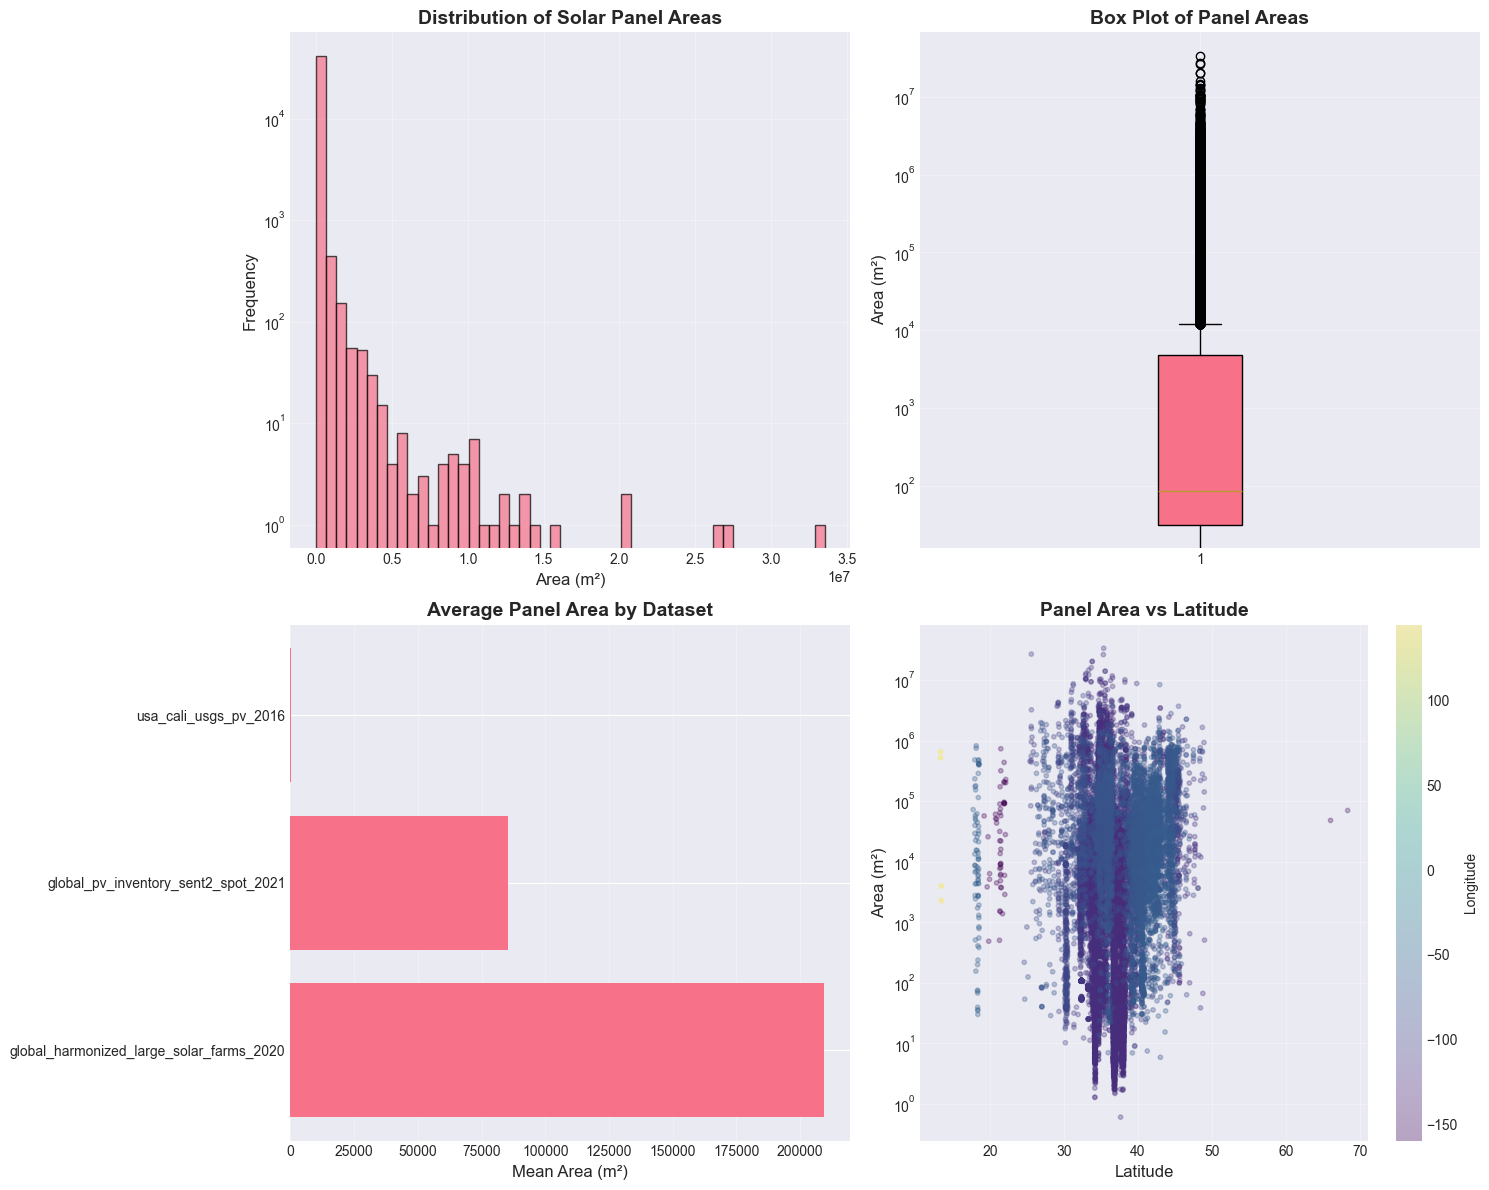

In [14]:
print("📊 Solar Panel Area Distribution Analysis\n")

# Compute statistics
area_stats = pv_gdf['area_m2'].describe()
print("Basic Statistics:")
print(area_stats)

# Additional percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
area_percentiles = pv_gdf['area_m2'].quantile([p/100 for p in percentiles])

print(f"\nDetailed Percentiles:")
for p, val in zip(percentiles, area_percentiles):
    print(f"   {p:2d}th: {val:10,.2f} m²")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram with log scale
axes[0, 0].hist(pv_gdf['area_m2'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Area (m²)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Solar Panel Areas', fontsize=14, fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot
axes[0, 1].boxplot(pv_gdf['area_m2'], vert=True, patch_artist=True)
axes[0, 1].set_ylabel('Area (m²)', fontsize=12)
axes[0, 1].set_title('Box Plot of Panel Areas', fontsize=14, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# 3. Area by dataset source
area_by_source = pv_gdf.groupby('dataset_name')['area_m2'].mean().sort_values(ascending=False)
axes[1, 0].barh(area_by_source.index, area_by_source.values)
axes[1, 0].set_xlabel('Mean Area (m²)', fontsize=12)
axes[1, 0].set_title('Average Panel Area by Dataset', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Scatter plot: Area vs Location (Latitude)
axes[1, 1].scatter(
    pv_gdf['centroid_lat'], 
    pv_gdf['area_m2'], 
    alpha=0.3, 
    s=10,
    c=pv_gdf['centroid_lon'],
    cmap='viridis'
)
axes[1, 1].set_xlabel('Latitude', fontsize=12)
axes[1, 1].set_ylabel('Area (m²)', fontsize=12)
axes[1, 1].set_title('Panel Area vs Latitude', fontsize=14, fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)
colorbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
colorbar.set_label('Longitude', fontsize=10)

plt.tight_layout()
plt.savefig('/Volumes/Expanse/repos/ice-mELT_ducklake/notebooks/01_area_distribution.png', 
            dpi=150, bbox_inches='tight')
print("\n💾 Saved plot: 01_area_distribution.png")
plt.show()

### 5.2 Geographic Distribution

🗺️ Geographic Distribution Analysis

💾 Saved plot: 01_geographic_distribution.png


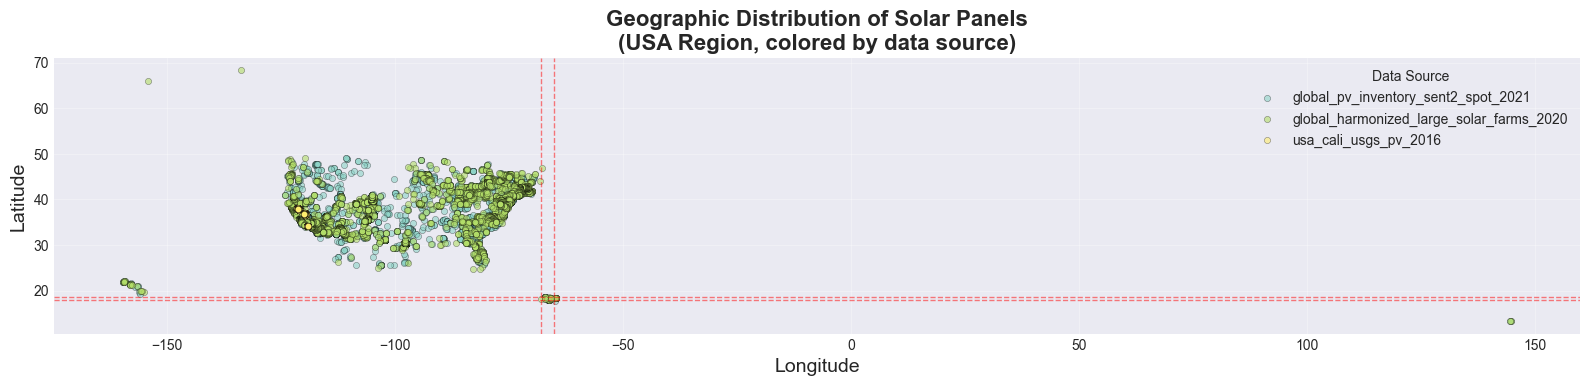

Distribution by Latitude Bands:
   Hawaii/PR (17-30°N): 419 installations (1.0%)
   South (30-35°N): 11,675 installations (27.4%)
   Mid (35-40°N): 25,590 installations (60.0%)
   North (40-45°N): 4,577 installations (10.7%)
   Far North (45-48°N): 380 installations (0.9%)


In [15]:
print("🗺️ Geographic Distribution Analysis\n")

# Create scatter plot of panel locations
fig, ax = plt.subplots(figsize=(16, 10))

# Color by dataset
sources = pv_gdf['dataset_name'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(sources)))

for i, source in enumerate(sources):
    subset = pv_gdf[pv_gdf['dataset_name'] == source]
    ax.scatter(
        subset['centroid_lon'],
        subset['centroid_lat'],
        c=[colors[i]],
        label=source,
        alpha=0.6,
        s=20,
        edgecolors='black',
        linewidth=0.3
    )

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title('Geographic Distribution of Solar Panels\n(USA Region, colored by data source)', 
             fontsize=16, fontweight='bold')
ax.legend(title='Data Source', loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

# Add bounding box annotation
ax.axvline(AOI_BBOX[0], color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(AOI_BBOX[2], color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(AOI_BBOX[1], color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(AOI_BBOX[3], color='red', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('/Volumes/Expanse/repos/ice-mELT_ducklake/notebooks/01_geographic_distribution.png',
            dpi=150, bbox_inches='tight')
print("💾 Saved plot: 01_geographic_distribution.png")
plt.show()

# Print summary by region (latitude bands)
print("Distribution by Latitude Bands:")
lat_bins = [17, 30, 35, 40, 45, 48]
lat_labels = ['Hawaii/PR (17-30°N)', 'South (30-35°N)', 'Mid (35-40°N)', 
              'North (40-45°N)', 'Far North (45-48°N)']
pv_gdf['lat_band'] = pd.cut(pv_gdf['centroid_lat'], bins=lat_bins, labels=lat_labels)

for band in lat_labels:
    count = (pv_gdf['lat_band'] == band).sum()
    if count > 0:
        pct = count / len(pv_gdf) * 100
        print(f"   {band}: {count:,} installations ({pct:.1f}%)")

### 5.3 Visualizing Polygon Geometries

Let's look at the actual shapes of the solar panels.


🎨 Visualizing Sampled Geometries



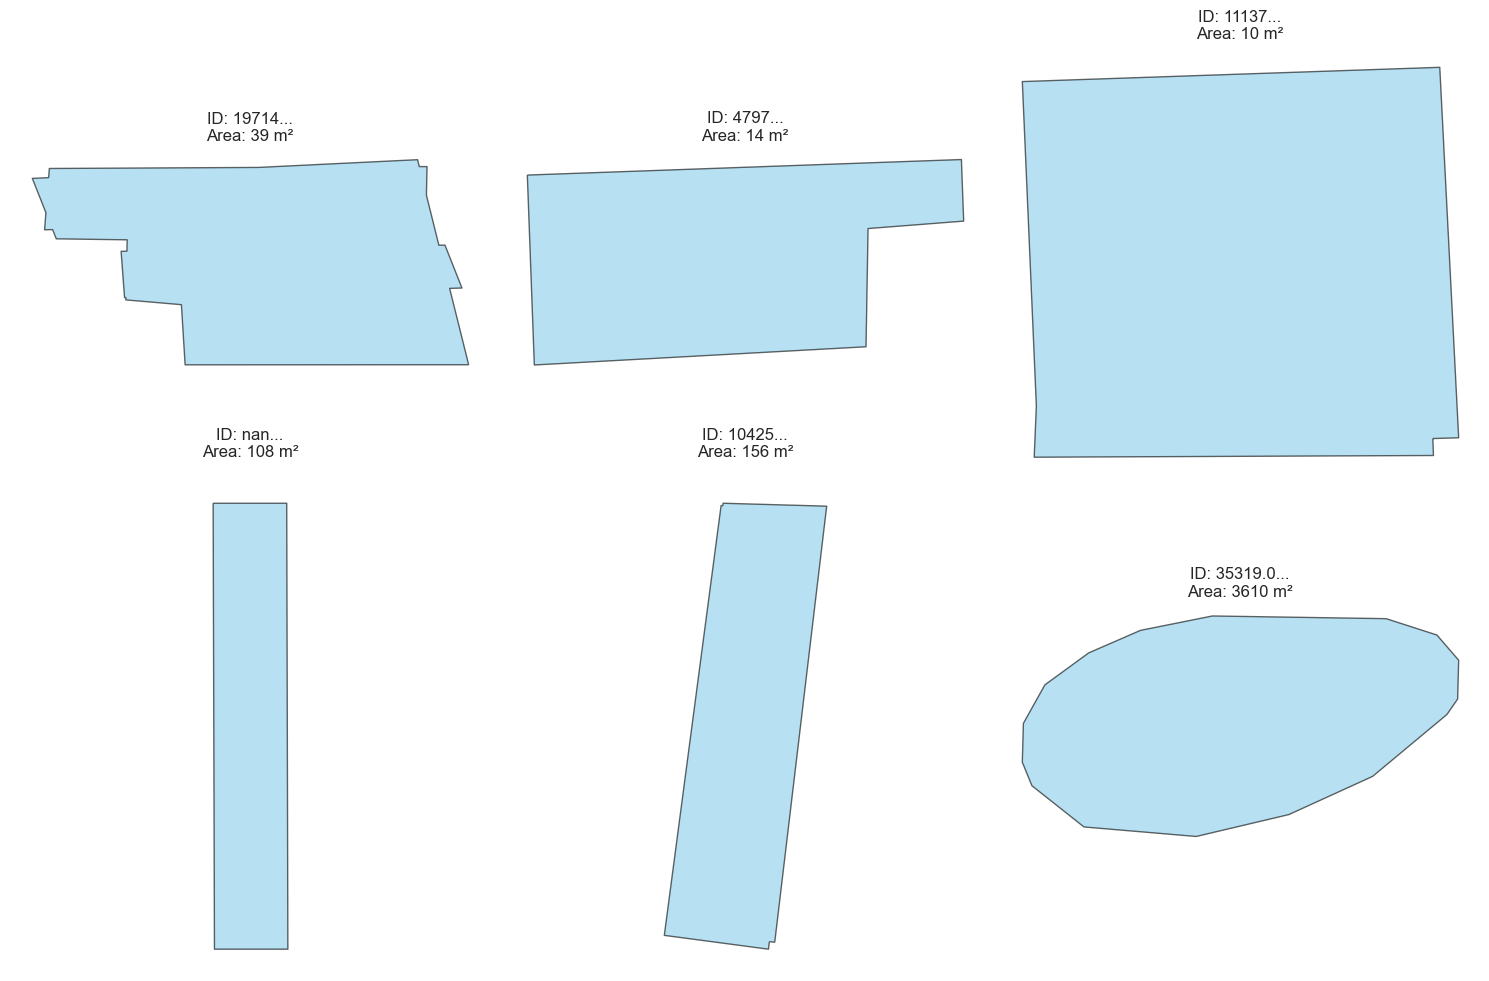

In [16]:
print("\n🎨 Visualizing Sampled Geometries\n")

# Sample a few polygons
# Filter for Polygons only to avoid issues with MultiPolygons in simple plot
poly_subset = pv_gdf[pv_gdf.geometry.type == 'Polygon']
if len(poly_subset) > 6:
    sample_polys = poly_subset.sample(n=6, random_state=42)
else:
    sample_polys = poly_subset

if len(sample_polys) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, (i, row) in enumerate(sample_polys.iterrows()):
        ax = axes[idx]
        # Plot the geometry
        gpd.GeoSeries([row.geometry]).plot(ax=ax, color='skyblue', edgecolor='black', alpha=0.6)
        ax.set_title(f"ID: {row['unified_id'][:8]}...\nArea: {row['area_m2']:.0f} m²")
        ax.axis('off')

    plt.tight_layout()
    # Save to a specific directory to avoid cluttering root
    # plt.savefig('/Volumes/Expanse/repos/ice-mELT_ducklake/notebooks/01_polygon_samples.png', dpi=150, bbox_inches='tight')
    # print("💾 Saved plot: 01_polygon_samples.png")
    plt.show()
else:
    print("⚠️ Not enough polygons to visualize.")

---

## 📝 Task 6: Data Quality Assessment

In [17]:
print("🔍 Data Quality Assessment\n")

# Check for missing values
print("1️⃣ Missing Values:")
missing = pv_gdf.isnull().sum()
missing_pct = (missing / len(pv_gdf) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    display(missing_df)
else:
    print("   ✅ No missing values found!")

# Check geometry validity
print("\n2️⃣ Geometry Validity:")
invalid_geoms = ~pv_gdf.geometry.is_valid
print(f"   Total geometries: {len(pv_gdf):,}")
print(f"   Valid: {pv_gdf.geometry.is_valid.sum():,}")
print(f"   Invalid: {invalid_geoms.sum():,}")

if invalid_geoms.sum() > 0:
    print("   ⚠️  Found invalid geometries - may need repair")

# Check for duplicate IDs
print("\n3️⃣ Duplicate Check:")
duplicate_ids = pv_gdf['unified_id'].duplicated().sum()
print(f"   Duplicate IDs: {duplicate_ids}")

# Data completeness score
print("\n4️⃣ Overall Data Quality Score:")
completeness_scores = {
    'Valid geometries': pv_gdf.geometry.is_valid.sum() / len(pv_gdf) * 100,
    'Has area data': pv_gdf['area_m2'].notna().sum() / len(pv_gdf) * 100,
    'Has coordinates': ((pv_gdf['centroid_lon'].notna()) & 
                        (pv_gdf['centroid_lat'].notna())).sum() / len(pv_gdf) * 100,
    'Unique IDs': (1 - pv_gdf['unified_id'].duplicated().sum() / len(pv_gdf)) * 100,
}

for metric, score in completeness_scores.items():
    status = "✅" if score > 95 else "⚠️" if score > 80 else "❌"
    print(f"   {status} {metric}: {score:.1f}%")

overall_score = np.mean(list(completeness_scores.values()))
print(f"\n   Overall Quality: {overall_score:.1f}%")

🔍 Data Quality Assessment

1️⃣ Missing Values:


,Column,Missing Count,Percentage
8,source_area_m2,34615,81.12
9,capacity_mw,33350,78.16
10,install_date,23607,55.33
11,lat_band,28,0.07



2️⃣ Geometry Validity:
   Total geometries: 42,669
   Valid: 42,669
   Invalid: 0

3️⃣ Duplicate Check:
   Duplicate IDs: 13832

4️⃣ Overall Data Quality Score:
   ✅ Valid geometries: 100.0%
   ✅ Has area data: 100.0%
   ✅ Has coordinates: 100.0%
   ❌ Unique IDs: 67.6%

   Overall Quality: 91.9%


---

## 🧹 Task 7: Spatial Deduplication

When combining data from multiple sources, duplicates are common.
We'll explore two methods to remove them:

1.  **GeoPandas Deduplication**: Exact geometry matching.
2.  **DuckDB + H3 Deduplication**: Spatial grid-based filtering.

### 7.1 GeoPandas Deduplication (Exact Match)

This method finds rows with identical geometries.

In [18]:
print("🧹 Method 1: GeoPandas Exact Deduplication\n")

initial_count = len(pv_gdf)
print(f"   Initial count: {initial_count:,}")

# Check for exact duplicates in geometry
# Note: This can be slow for large datasets as it compares every geometry
duplicates_mask = pv_gdf.geometry.duplicated()
num_duplicates = duplicates_mask.sum()

print(f"   Exact geometry duplicates found: {num_duplicates:,}")

pv_gdf_dedup = pv_gdf[~duplicates_mask].copy()
print(f"   Count after GeoPandas deduplication: {len(pv_gdf_dedup):,}")

🧹 Method 1: GeoPandas Exact Deduplication

   Initial count: 42,669
   Exact geometry duplicates found: 660
   Count after GeoPandas deduplication: 42,009


### 7.2 DuckDB + H3 Deduplication (Spatial Grid)

We can use **DuckDB** and **H3** (Uber's Hexagonal Hierarchical Spatial Index) for efficient spatial deduplication.

**Strategy:**
1.  Assign a **very high resolution** H3 cell (Resolution 15, ~0.9 m²) to each centroid.
2.  Group by this H3 cell.
3.  Keep only one record per cell (e.g., the one with the largest area).

This handles "fuzzy" duplicates where coordinates might differ slightly but represent the same object.

In [19]:
print("\n🦆 Method 2: DuckDB + H3 Spatial Deduplication\n")

import duckdb

# Connect to DuckDB (in-memory for processing)
con = duckdb.connect(database=':memory:')

# Install and load spatial extension
# Note: In some environments, extensions need internet access to install
con.execute("INSTALL spatial; LOAD spatial;")
print("   ✅ DuckDB spatial extension loaded")
# load h3 extension (needed for h3_latlng_to_cell)
con.execute("INSTALL h3 FROM community; LOAD h3;")
print("   ✅ DuckDB h3 extension loaded")

# Register our dataframe
# Convert geometry to WKT for DuckDB compatibility
pv_duck_prep = pv_gdf.copy()
pv_duck_prep['geometry'] = pv_duck_prep.geometry.apply(lambda geom: geom.wkb)
con.register('pv_data', pv_duck_prep)


🦆 Method 2: DuckDB + H3 Spatial Deduplication

   ✅ DuckDB spatial extension loaded
   ✅ DuckDB h3 extension loaded


/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_42920/1022644350.py:19: UserWarning:

Geometry column does not contain geometry.



In [20]:
# Perform deduplication using SQL
# We'll use H3 Resolution 15 (very fine grain) to approximate "same location"
# We use the existing h3_index_8 to optimize if needed, but here we calculate fresh high-res indices

# make sure geometry is fetched as WKT to avoid WKB byte parsing issues
query = """
WITH with_h3 AS (
    SELECT
        *,
        -- Calculate high-res H3 index for the centroid (Resolution 15)
        -- Note: Function name might vary by version, usually h3_latlng_to_cell or h3_point
        h3_latlng_to_cell(centroid_lat, centroid_lon, 15) as h3_highres
    FROM pv_data
),
deduplicated AS (
    SELECT ST_AsText(ST_GeomFromWKB(geometry)) as geometry, * EXCLUDE(geometry)
    FROM with_h3
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY h3_highres
        ORDER BY area_m2 DESC  -- Keep the largest polygon if duplicates exist
    ) = 1
)
SELECT * FROM deduplicated
"""

try:
    print("   🏃 Running DuckDB deduplication...")
    start_time = datetime.now()
    pv_duck_dedup = con.execute(query).df()
    end_time = datetime.now()
    # load geometry from WKB
    pv_duck_dedup['geometry'] = pv_duck_dedup['geometry'].apply(wkt.loads)
    # convert back to geodataframe
    pv_duck_dedup = gpd.GeoDataFrame(pv_duck_dedup, geometry='geometry', crs='EPSG:4326')

    print(f"   ✅ Done in {(end_time - start_time).total_seconds():.2f}s")
    print(f"   Count after DuckDB/H3 deduplication: {len(pv_duck_dedup):,}")
    
    DUCKDB_SUCCESS = True
except Exception as e:
    print(f"   ❌ DuckDB deduplication failed: {e}")
    print("   (Check if H3 functions are available in this DuckDB version)")
    pv_duck_dedup = pv_gdf_dedup # Fallback
    DUCKDB_SUCCESS = False

   🏃 Running DuckDB deduplication...
   ✅ Done in 0.19s
   Count after DuckDB/H3 deduplication: 41,867


In [21]:
pv_duck_dedup.geometry.dtype

### 7.3 Comparison

In [22]:
if DUCKDB_SUCCESS:
    print("\n⚖️ Comparison of Results:\n")

    gpd_count = len(pv_gdf_dedup)
    duck_count = len(pv_duck_dedup)

    print(f"   Original:        {initial_count:,}")
    print(f"   GeoPandas (Exact): {gpd_count:,} (Removed {initial_count - gpd_count:,})")
    print(f"   DuckDB (H3 Res 15): {duck_count:,} (Removed {initial_count - duck_count:,})")

    diff = abs(gpd_count - duck_count)
    print(f"\n   Difference: {diff:,} records")

    if diff < (initial_count * 0.01):
        print("   ✅ Results match closely!")
    else:
        print("   ℹ️  Results differ - H3 might be catching fuzzy duplicates that exact match missed.")


⚖️ Comparison of Results:

   Original:        42,669
   GeoPandas (Exact): 42,009 (Removed 660)
   DuckDB (H3 Res 15): 41,867 (Removed 802)

   Difference: 142 records
   ✅ Results match closely!


---

## 💾 Task 8: Saving Data

We will save our processed, deduplicated data to a persistent DuckDB database.

In [23]:
print("💾 Saving to Persistent DuckDB\n")

# Ensure db directory exists
os.makedirs('db', exist_ok=True)

db_path = os.getenv('PROJECT_DB', '../db/pv_project.ddb')
print(f"   Database: {db_path}")

# Connect to persistent DB
con_persistent = duckdb.connect(db_path)
# install spatial and httpfs extensions 
con_persistent.execute("INSTALL spatial; LOAD spatial;")
con_persistent.execute("INSTALL httpfs; LOAD httpfs;")

# Write the deduplicated dataframe to a table
# We prefer the DuckDB result if available, else GeoPandas result
final_df = pv_duck_dedup if DUCKDB_SUCCESS else pv_gdf_dedup

try:
    # Convert geometry to WKT for DuckDB storage (if it's not already strings)
    final_df_storage = final_df
    # drop any invalid geometries before saving
    og_len = len(final_df_storage)
    final_df_storage = final_df_storage[final_df_storage.is_valid].copy()
    print(f"   Dropped {og_len - len(final_df_storage):,} invalid geometries before saving.")

    # make sure geometry is either WKT or WKB for conversion to duckdb Geometry type
    if str(final_df_storage['geometry'].dtype) == 'geometry':
        final_df_storage['geometry'] = final_df_storage['geometry'].apply(lambda geom: geom.wkb)
    
    # process reading WKB/WKT geometry into Geometry data type for duckdb
    # save as WKT for compatibility and easier retrieval wi
    con_persistent.execute("""
        CREATE OR REPLACE TABLE processed_pv_data AS
            SELECT ST_GeomFromWKB(geometry) as geometry, * EXCLUDE (geometry) FROM final_df_storage
        """)
    print("   ✅ Data saved to table 'processed_pv_data'")
    
    # Verify
    count = con_persistent.execute("SELECT count(*) FROM processed_pv_data").fetchone()[0]
    print(f"   Verified count in DB: {count:,}")
    
except Exception as e:
    print(f"   ❌ Error saving to DB: {e}")

con_persistent.close()
con.close()

💾 Saving to Persistent DuckDB

   Database: ../db/pv_project.ddb
   Dropped 0 invalid geometries before saving.


/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_42920/2027967802.py:29: UserWarning:

Geometry column does not contain geometry.



   ✅ Data saved to table 'processed_pv_data'
   Verified count in DB: 41,867


---

## 🎓 Summary: What We Learned

### Key Concepts Covered

1. **Loading Geospatial Data**
   - Reading GeoParquet from cloud storage (S3/R2)
   - Using pandas + s3fs for data access
   - Filtering data by bounding box and sampling

2. **GeoPandas Fundamentals**
   - Converting WKT strings to Shapely geometries
   - Creating GeoDataFrames with proper CRS
   - Understanding geometry types (Polygon, MultiPolygon)

3. **Spatial Operations**
   - Computing geometric properties (area, centroid, bounds)
   - Working with different geometry types
   - Coordinate Reference Systems (CRS)
   - Transforming between projections

4. **Spatial Analysis**
   - Filtering by bounding box
   - Testing spatial relationships (intersects, distance)
   - Combining spatial and attribute filters

5. **Exploratory Analysis**
   - Distribution analysis (area, location)
   - Visualization with matplotlib
   - Summary statistics by region

6. **Data Quality**
   - Checking for missing values
   - Validating geometries
   - Assessing data completeness

7. **Spatial Deduplication**
   - Identifying duplicates using GeoPandas (exact match)
   - Using DuckDB + H3 for spatial grid-based deduplication
   - Comparing results between methods
   - Saving processed data to persistent DuckDB

### Next Steps

In **Notebook 2**, we'll explore:
- Interactive visualizations with Folium
- Creating choropleth maps
- Adding popups and tooltips
- Layering multiple datasets
- Export to HTML for web viewing

### Resources for Further Learning

- [GeoPandas Documentation](https://geopandas.org/en/stable/)
- [Shapely User Manual](https://shapely.readthedocs.io/)
- [Working with Geospatial Data in Python](https://geographicdata.science/book/)
- [GeoParquet Specification](https://geoparquet.org/)